# Small Business Credit Access and Business Formation in Georgia

### An Analysis of SBA 7(a) Lending and Census Business Dynamics, 2020–2023

**Research Question:**  
Is access to SBA-backed small-business credit associated with higher rates of new-business formation across Georgia counties?

This project combines U.S. Small Business Administration 7(a) lending records with U.S. Census Business Dynamics Statistics (BDS) to examine county-level differences in credit access and establishment formation across Georgia.

The analysis evaluates SBA lending intensity, estimates its relationship with establishment entry rates, tests the robustness of that relationship, and identifies potential geographic mismatches between entrepreneurial activity and SBA lending.

## 1. Setup & Data Loading

This section imports the Python libraries used throughout the analysis, connects the notebook to Google Drive, and loads the raw SBA 7(a) and Census Business Dynamics Statistics datasets.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup complete.")

Mounted at /content/drive
Setup complete.


In [2]:
# Permanent file locations in Google Drive

SBA_FILE = "/content/drive/MyDrive/SBA_Project/FOIA_7a_FY2020_Present_asof_260630.csv"
BDS_FILE = "/content/drive/MyDrive/SBA_Project/bds2023_st_cty (1).csv"

# Load both datasets
sba = pd.read_csv(SBA_FILE, low_memory=False)
bds = pd.read_csv(BDS_FILE, low_memory=False)

print("SBA rows:", len(sba))
print("SBA columns:", len(sba.columns))

print("BDS rows:", len(bds))
print("BDS columns:", len(bds.columns))

print("\nBoth datasets loaded successfully.")

SBA rows: 388338
SBA columns: 42
BDS rows: 146924
BDS columns: 27

Both datasets loaded successfully.


## 2. SBA Data Cleaning

The raw SBA dataset contains loan-level records from across the United States. This section retains the variables relevant to the analysis, isolates Georgia loans, standardizes county names, and aggregates individual loans into county-year lending measures.

In [3]:
# Keep only the SBA variables we actually need
sba_cols = [
    "GrossApproval",
    "ApprovalFY",
    "ProjectCounty",
    "ProjectState",
    "JobsSupported"
]

sba_clean = sba[sba_cols].copy()

print("Rows:", len(sba_clean))
print("Columns:", len(sba_clean.columns))

sba_clean.head()

Rows: 388338
Columns: 5


,GrossApproval,ApprovalFY,ProjectCounty,ProjectState,JobsSupported
0,25000.0,2020,MONTGOMERY,PA,5.0
1,95800.0,2020,QUEENS,NY,3.0
2,40000.0,2020,PLACER,CA,0.0
3,125000.0,2020,GUADALUPE,TX,3.0
4,250000.0,2020,HARRIS,TX,4.0


In [4]:
# Keep only Georgia SBA loans
ga_sba = sba_clean[
    sba_clean["ProjectState"] == "GA"
].copy()

print("Georgia SBA loans:", len(ga_sba))
print("Years:", sorted(ga_sba["ApprovalFY"].unique()))

ga_sba.head(10)

Georgia SBA loans: 11597
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


,GrossApproval,ApprovalFY,ProjectCounty,ProjectState,JobsSupported
16,1035000.0,2020,GWINNETT,GA,8.0
26,90000.0,2020,COBB,GA,1.0
31,245000.0,2020,FAYETTE,GA,10.0
91,750000.0,2020,GILMER,GA,2.0
177,1895000.0,2020,BIBB,GA,6.0
206,2327000.0,2020,GWINNETT,GA,5.0
243,175000.0,2020,GWINNETT,GA,5.0
254,459000.0,2020,COFFEE,GA,17.0
277,3725000.0,2020,GWINNETT,GA,40.0
284,1935000.0,2020,COBB,GA,5.0


In [5]:
# Summarize SBA lending by county and year

ga_sba["ProjectCounty"] = (
    ga_sba["ProjectCounty"]
    .astype(str)
    .str.strip()
    .str.upper()
)

sba_county_year = (
    ga_sba
    .groupby(["ApprovalFY", "ProjectCounty"])
    .agg(
        Number_of_Loans=("GrossApproval", "count"),
        Total_Lending=("GrossApproval", "sum"),
        Average_Loan=("GrossApproval", "mean"),
        Jobs_Supported=("JobsSupported", "sum")
    )
    .reset_index()
)

sba_county_year = sba_county_year.rename(
    columns={
        "ApprovalFY": "year",
        "ProjectCounty": "county_name"
    }
)

print("County-year rows:", len(sba_county_year))
print("Unique counties:", sba_county_year["county_name"].nunique())

sba_county_year.head(10)

County-year rows: 774
Unique counties: 150


,year,county_name,Number_of_Loans,Total_Lending,Average_Loan,Jobs_Supported
0,2020,ATKINSON,1,1584000.0,1.584000e+06,1.0
1,2020,BACON,2,3128000.0,1.564000e+06,39.0
2,2020,BALDWIN,2,2205000.0,1.102500e+06,34.0
3,2020,BANKS,4,2743000.0,6.857500e+05,36.0
4,2020,BARROW,9,3453500.0,3.837222e+05,89.0
5,2020,BARTOW,9,11596000.0,1.288444e+06,178.0
6,2020,BEN HILL,1,150000.0,1.500000e+05,1.0
7,2020,BIBB,17,18118300.0,1.065782e+06,362.0
8,2020,BROOKS,1,675000.0,6.750000e+05,5.0
9,2020,BRYAN,4,4784700.0,1.196175e+06,40.0


In [6]:
# Inspect the BDS dataset before cleaning

print("BDS rows:", len(bds))
print("BDS columns:", len(bds.columns))

print("\nColumn names:")
print(bds.columns.tolist())

bds.head()

BDS rows: 146924
BDS columns: 27

Column names:
['year', 'st', 'cty', 'firms', 'estabs', 'emp', 'denom', 'estabs_entry', 'estabs_entry_rate', 'estabs_exit', 'estabs_exit_rate', 'job_creation', 'job_creation_births', 'job_creation_continuers', 'job_creation_rate_births', 'job_creation_rate', 'job_destruction', 'job_destruction_deaths', 'job_destruction_continuers', 'job_destruction_rate_deaths', 'job_destruction_rate', 'net_job_creation', 'net_job_creation_rate', 'reallocation_rate', 'firmdeath_firms', 'firmdeath_estabs', 'firmdeath_emp']


,year,st,cty,firms,estabs,emp,denom,estabs_entry,estabs_entry_rate,estabs_exit,...,job_destruction_deaths,job_destruction_continuers,job_destruction_rate_deaths,job_destruction_rate,net_job_creation,net_job_creation_rate,reallocation_rate,firmdeath_firms,firmdeath_estabs,firmdeath_emp
0,1978,1,1,422,430,5414,5191,98,23.815,61,...,718,256,13.833,18.765,441,8.496,37.530,42,42,108
1,1978,1,3,1432,1540,14763,13991,312,21.196,176,...,660,1247,4.717,13.631,1474,10.536,27.261,144,145,539
2,1978,1,5,441,466,5488,5134,71,15.401,61,...,157,442,3.058,11.667,680,13.245,23.335,48,48,129
3,1978,1,7,188,192,2806,2726,33,17.143,34,...,101,353,3.706,16.657,164,6.017,33.315,30,30,87
4,1978,1,9,412,422,3877,3695,70,17.032,48,...,196,233,5.305,11.612,359,9.717,23.224,36,36,123


## 3. Census BDS Data Cleaning

The Census Business Dynamics Statistics dataset provides county-level measures of firms, establishments, and establishment entry. This section isolates Georgia observations, restricts the analysis to 2020–2023, removes the statewide aggregate, creates county FIPS codes, and converts suppressed/text variables into numeric form.

In [7]:
# Keep Georgia BDS data for the years we can compare with SBA data

ga_bds = bds[
    (bds["st"] == 13) &
    (bds["year"] >= 2020)
].copy()

print("Georgia BDS rows:", len(ga_bds))
print("Years:", sorted(ga_bds["year"].unique()))
print("County codes:", ga_bds["cty"].nunique())

ga_bds[
    [
        "year",
        "st",
        "cty",
        "firms",
        "estabs",
        "estabs_entry",
        "estabs_entry_rate"
    ]
].head(10)

Georgia BDS rows: 640
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
County codes: 160


,year,st,cty,firms,estabs,estabs_entry,estabs_entry_rate
134546,2020,13,1,321,340,23,6.706
134547,2020,13,3,80,86,3,3.429
134548,2020,13,5,211,218,19,8.756
134549,2020,13,7,28,29,3,10.169
134550,2020,13,9,710,773,57,7.379
134551,2020,13,11,272,278,18,6.498
134552,2020,13,13,1155,1216,146,12.167
134553,2020,13,15,1863,2025,188,9.282
134554,2020,13,17,270,280,17,6.018
134555,2020,13,19,216,231,28,12.389


In [8]:
# Remove Georgia statewide aggregate (cty = 999)

ga_bds_clean = ga_bds[
    ga_bds["cty"] != 999
].copy()

print("Rows after removing statewide aggregate:", len(ga_bds_clean))
print("Counties:", ga_bds_clean["cty"].nunique())
print("Years:", sorted(ga_bds_clean["year"].unique()))

Rows after removing statewide aggregate: 636
Counties: 159
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [9]:
# Create 5-digit county FIPS code

ga_bds_clean["county_fips"] = (
    ga_bds_clean["st"].astype(str).str.zfill(2)
    +
    ga_bds_clean["cty"].astype(str).str.zfill(3)
)

print("Unique FIPS codes:", ga_bds_clean["county_fips"].nunique())

ga_bds_clean[
    ["year", "st", "cty", "county_fips", "firms", "estabs_entry", "estabs_entry_rate"]
].head(10)

Unique FIPS codes: 159


,year,st,cty,county_fips,firms,estabs_entry,estabs_entry_rate
134546,2020,13,1,13001,321,23,6.706
134547,2020,13,3,13003,80,3,3.429
134548,2020,13,5,13005,211,19,8.756
134549,2020,13,7,13007,28,3,10.169
134550,2020,13,9,13009,710,57,7.379
134551,2020,13,11,13011,272,18,6.498
134552,2020,13,13,13013,1155,146,12.167
134553,2020,13,15,13015,1863,188,9.282
134554,2020,13,17,13017,270,17,6.018
134555,2020,13,19,13019,216,28,12.389


## 4. County Matching & Data Merge

The SBA and Census datasets identify counties differently. This section converts SBA county names to official FIPS codes, restricts SBA observations to the shared 2020–2023 period, and merges the two datasets by county and year.

In [10]:
!pip -q install addfips

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 5.4 MB/s eta 0:00:00


In [11]:
import addfips

af = addfips.AddFIPS()

# Quick test before we use it on the dataset
print("Fulton:", af.get_county_fips("Fulton", state="GA"))
print("Cobb:", af.get_county_fips("Cobb", state="GA"))
print("Gwinnett:", af.get_county_fips("Gwinnett", state="GA"))

Fulton: 13121
Cobb: 13067
Gwinnett: 13135


In [12]:
# Add county FIPS codes to SBA county-year data

sba_county_year["county_fips"] = sba_county_year["county_name"].apply(
    lambda x: af.get_county_fips(str(x).title(), state="GA")
)

print("Missing FIPS codes:", sba_county_year["county_fips"].isnull().sum())

print("\nUnmatched counties:")
print(
    sba_county_year.loc[
        sba_county_year["county_fips"].isnull(),
        "county_name"
    ].drop_duplicates().tolist()
)

Missing FIPS codes: 0

Unmatched counties:
[]


In [13]:
# Keep only overlapping years: 2020–2023

sba_recent = sba_county_year[
    sba_county_year["year"].between(2020, 2023)
].copy()

# Merge BDS business data with SBA lending data
merged = pd.merge(
    ga_bds_clean,
    sba_recent[
        [
            "year",
            "county_fips",
            "Number_of_Loans",
            "Total_Lending",
            "Average_Loan",
            "Jobs_Supported"
        ]
    ],
    on=["year", "county_fips"],
    how="left"
)

print("Merged rows:", len(merged))
print("Counties:", merged["county_fips"].nunique())
print("Years:", sorted(merged["year"].unique()))

print("\nMissing SBA loan counts:")
print(merged["Number_of_Loans"].isnull().sum())

Merged rows: 636
Counties: 159
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Missing SBA loan counts:
178


In [14]:
# Fill county-years with no SBA lending activity with zero

sba_zero_cols = [
    "Number_of_Loans",
    "Total_Lending",
    "Average_Loan",
    "Jobs_Supported"
]

merged[sba_zero_cols] = merged[sba_zero_cols].fillna(0)

# Verify
print("Rows:", len(merged))
print("Counties:", merged["county_fips"].nunique())
print("Missing SBA values:")
print(merged[sba_zero_cols].isnull().sum())

Rows: 636
Counties: 159
Missing SBA values:
Number_of_Loans    0
Total_Lending      0
Average_Loan       0
Jobs_Supported     0
dtype: int64


In [15]:
# Convert BDS variables to numeric
numeric_cols = [
    "firms",
    "estabs",
    "estabs_entry",
    "estabs_entry_rate"
]

for col in numeric_cols:
    merged[col] = pd.to_numeric(
        merged[col],
        errors="coerce"
    )

print(merged[numeric_cols].dtypes)

print("\nMissing values after conversion:")
print(merged[numeric_cols].isnull().sum())

firms                  int64
estabs                 int64
estabs_entry         float64
estabs_entry_rate    float64
dtype: object

Missing values after conversion:
firms                 0
estabs                0
estabs_entry         16
estabs_entry_rate    16
dtype: int64


## 5. Credit Access Measures

Raw SBA loan totals are not directly comparable across counties because counties differ substantially in the size of their business sectors. This section creates normalized measures of SBA lending relative to the number of firms in each county.

In [16]:
# Create SBA credit-access measures

merged["Loans_per_1000_Firms"] = (
    merged["Number_of_Loans"] / merged["firms"] * 1000
)

merged["Lending_per_Firm"] = (
    merged["Total_Lending"] / merged["firms"]
)

merged[
    [
        "year",
        "county_fips",
        "firms",
        "Number_of_Loans",
        "Total_Lending",
        "Loans_per_1000_Firms",
        "Lending_per_Firm",
        "estabs_entry_rate"
    ]
].head(10)

,year,county_fips,firms,Number_of_Loans,Total_Lending,Loans_per_1000_Firms,Lending_per_Firm,estabs_entry_rate
0,2020,13001,321,0.0,0.0,0.000000,0.000000,6.706
1,2020,13003,80,1.0,1584000.0,12.500000,19800.000000,3.429
2,2020,13005,211,2.0,3128000.0,9.478673,14824.644550,8.756
3,2020,13007,28,0.0,0.0,0.000000,0.000000,10.169
4,2020,13009,710,2.0,2205000.0,2.816901,3105.633803,7.379
5,2020,13011,272,4.0,2743000.0,14.705882,10084.558824,6.498
6,2020,13013,1155,9.0,3453500.0,7.792208,2990.043290,12.167
7,2020,13015,1863,9.0,11596000.0,4.830918,6224.369297,9.282
8,2020,13017,270,1.0,150000.0,3.703704,555.555556,6.018
9,2020,13019,216,0.0,0.0,0.000000,0.000000,12.389


In [17]:
# Create final analysis dataset

analysis = merged[
    [
        "year",
        "county_fips",
        "firms",
        "Number_of_Loans",
        "Total_Lending",
        "Loans_per_1000_Firms",
        "Lending_per_Firm",
        "estabs_entry_rate"
    ]
].dropna(subset=["estabs_entry_rate"]).copy()

print("Total merged observations:", len(merged))
print("Usable analysis observations:", len(analysis))
print("Observations removed for missing entry rate:",
      len(merged) - len(analysis))

print("\nYears:")
print(analysis["year"].value_counts().sort_index())

Total merged observations: 636
Usable analysis observations: 620
Observations removed for missing entry rate: 16

Years:
year
2020    156
2021    155
2022    153
2023    156
Name: count, dtype: int64


## 8. Robustness Checks

Two robustness tests examine whether the main relationship is sensitive to the composition of the sample.

First, county-years with fewer than 100 firms are excluded to reduce instability caused by very small business populations. Second, the analysis is restricted to county-years that received at least one SBA loan to determine whether the relationship persists among counties already participating in SBA lending.

In [18]:
# Examine correlations between SBA credit access and business formation

correlations = analysis[
    [
        "estabs_entry_rate",
        "Loans_per_1000_Firms",
        "Lending_per_Firm"
    ]
].corr()

correlations

,estabs_entry_rate,Loans_per_1000_Firms,Lending_per_Firm
estabs_entry_rate,1.000000,0.141716,-0.025047
Loans_per_1000_Firms,0.141716,1.000000,0.708770
Lending_per_Firm,-0.025047,0.708770,1.000000


In [19]:
from scipy.stats import pearsonr

# Correlation significance tests

r_loans, p_loans = pearsonr(
    analysis["Loans_per_1000_Firms"],
    analysis["estabs_entry_rate"]
)

r_dollars, p_dollars = pearsonr(
    analysis["Lending_per_Firm"],
    analysis["estabs_entry_rate"]
)

print("SBA loans per 1,000 firms vs. business entry rate")
print("Correlation:", round(r_loans, 4))
print("P-value:", round(p_loans, 4))

print("\nSBA lending per firm vs. business entry rate")
print("Correlation:", round(r_dollars, 4))
print("P-value:", round(p_dollars, 4))

SBA loans per 1,000 firms vs. business entry rate
Correlation: 0.1417
P-value: 0.0004

SBA lending per firm vs. business entry rate
Correlation: -0.025
P-value: 0.5336


### Preliminary Finding

SBA loan frequency is positively but modestly correlated with establishment entry rates (r = 0.142, p < 0.001). In contrast, total SBA lending dollars per firm show essentially no relationship with establishment entry rates.

These correlations describe association rather than causation and do not account for differences across years or other county characteristics.

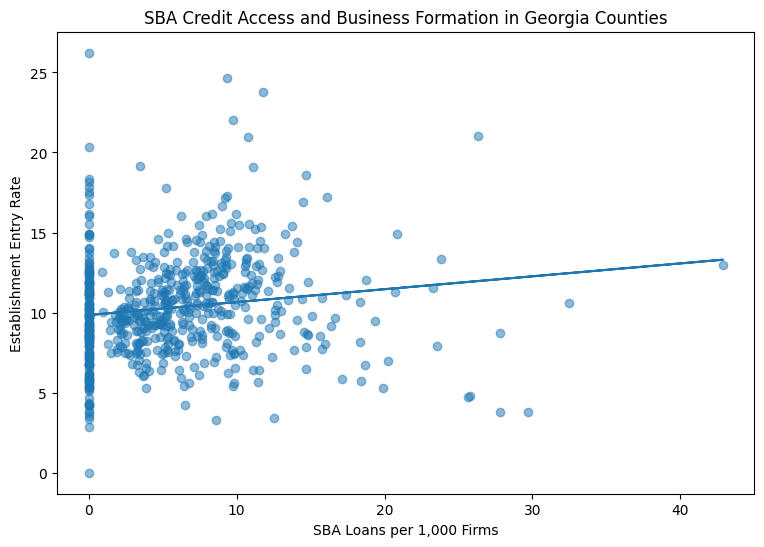

In [20]:
# Plot SBA loan access vs. business formation

import matplotlib.pyplot as plt
import numpy as np

x = analysis["Loans_per_1000_Firms"]
y = analysis["estabs_entry_rate"]

plt.figure(figsize=(9, 6))

plt.scatter(x, y, alpha=0.5)

# Add linear trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("SBA Loans per 1,000 Firms")
plt.ylabel("Establishment Entry Rate")
plt.title("SBA Credit Access and Business Formation in Georgia Counties")

plt.show()

## 7. Regression Analysis

To test whether SBA credit access remains associated with business formation after accounting for economy-wide differences across years, this section estimates an ordinary least squares (OLS) regression with year fixed effects.

The dependent variable is the county establishment entry rate, while the primary explanatory variable is SBA loans per 1,000 firms. The results should be interpreted as associations rather than causal effects.

In [21]:
import statsmodels.formula.api as smf

# Regression:
# Does SBA loan availability predict business formation
# after accounting for differences between years?

model = smf.ols(
    "estabs_entry_rate ~ Loans_per_1000_Firms + C(year)",
    data=analysis
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      estabs_entry_rate   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     12.12
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           1.72e-09
Time:                        03:04:58   Log-Likelihood:                -1571.6
No. Observations:                 620   AIC:                             3153.
Df Residuals:                     615   BIC:                             3175.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                8.7381 

In [22]:
# Translate regression result into an easier economic interpretation

coef = model.params["Loans_per_1000_Firms"]
p_value = model.pvalues["Loans_per_1000_Firms"]

print("Estimated effect:", round(coef, 4))
print("P-value:", round(p_value, 4))

print(
    "\nInterpretation: Holding year constant, "
    "10 additional SBA loans per 1,000 firms are associated with about",
    round(coef * 10, 2),
    "percentage points higher establishment entry rate."
)

Estimated effect: 0.0731
P-value: 0.0013

Interpretation: Holding year constant, 10 additional SBA loans per 1,000 firms are associated with about 0.73 percentage points higher establishment entry rate.


### Main Finding

SBA lending intensity is positively associated with new-business formation across Georgia counties. Holding year constant, 10 additional SBA 7(a) loans per 1,000 existing firms are associated with approximately a **0.73 percentage-point higher establishment entry rate**.

The estimated relationship is statistically significant (p = 0.0013). However, the model explains only a portion of variation in business formation, and the observational design does not establish that SBA lending causes higher establishment entry.

In [23]:
# Create standardized measures within each year

analysis["entry_z"] = analysis.groupby("year")["estabs_entry_rate"].transform(
    lambda x: (x - x.mean()) / x.std()
)

analysis["lending_z"] = analysis.groupby("year")["Loans_per_1000_Firms"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Positive credit_gap =
# business formation is stronger than SBA loan access would suggest
analysis["credit_gap"] = analysis["entry_z"] - analysis["lending_z"]

print("Credit gap created successfully.")

analysis[
    [
        "year",
        "county_fips",
        "estabs_entry_rate",
        "Loans_per_1000_Firms",
        "credit_gap"
    ]
].head(10)

Credit gap created successfully.


,year,county_fips,estabs_entry_rate,Loans_per_1000_Firms,credit_gap
0,2020,13001,6.706,0.000000,0.072921
1,2020,13003,3.429,12.500000,-3.996279
2,2020,13005,8.756,9.478673,-1.230740
3,2020,13007,10.169,0.000000,1.433697
4,2020,13009,7.379,2.816901,-0.289445
5,2020,13011,6.498,14.705882,-3.281179
6,2020,13013,12.167,7.792208,0.484877
7,2020,13015,9.282,4.830918,0.010173
8,2020,13017,6.018,3.703704,-1.021579
9,2020,13019,12.389,0.000000,2.306041


In [24]:
# Build county-name lookup using the SBA county field

county_lookup = (
    ga_sba[["ProjectCounty"]]
    .dropna()
    .drop_duplicates()
    .sort_values("ProjectCounty")
)

print("Number of unique SBA county names:", len(county_lookup))
print(county_lookup.head(20))

Number of unique SBA county names: 150
       ProjectCounty
57067        APPLING
35196       ATKINSON
10011          BACON
1397         BALDWIN
17131          BANKS
2520          BARROW
9286          BARTOW
22503       BEN HILL
44676        BERRIEN
177             BIBB
92119       BLECKLEY
73312       BRANTLEY
7152          BROOKS
1948           BRYAN
2864         BULLOCH
29662          BURKE
10616          BUTTS
246454       CALHOUN
2261          CAMDEN
32768        CANDLER


In [25]:
# Add FIPS codes to the SBA county lookup

county_lookup["county_fips"] = county_lookup["ProjectCounty"].apply(
    lambda x: af.get_county_fips(str(x).title(), state="GA")
)

print("Missing FIPS codes:", county_lookup["county_fips"].isnull().sum())

county_lookup.head(20)

Missing FIPS codes: 0


,ProjectCounty,county_fips
57067,APPLING,13001
35196,ATKINSON,13003
10011,BACON,13005
1397,BALDWIN,13009
17131,BANKS,13011
2520,BARROW,13013
9286,BARTOW,13015
22503,BEN HILL,13017
44676,BERRIEN,13019
177,BIBB,13021


In [26]:
# Attach available county names to the analysis data

analysis_named = analysis.merge(
    county_lookup[["county_fips", "ProjectCounty"]],
    on="county_fips",
    how="left"
)

analysis_named = analysis_named.rename(
    columns={"ProjectCounty": "county_name"}
)

print("Analysis rows:", len(analysis_named))
print("Rows missing a county name:", analysis_named["county_name"].isnull().sum())

print("\nFIPS codes still missing names:")
print(
    analysis_named.loc[
        analysis_named["county_name"].isnull(),
        "county_fips"
    ].drop_duplicates().tolist()
)

Analysis rows: 620
Rows missing a county name: 29

FIPS codes still missing names:
['13007', '13049', '13101', '13125', '13141', '13209', '13239', '13259', '13273']


In [27]:
# Fill county names for counties with no SBA records

missing_county_names = {
    "13007": "BAKER",
    "13049": "CHARLTON",
    "13101": "ECHOLS",
    "13125": "GLASCOCK",
    "13141": "HANCOCK",
    "13209": "MONTGOMERY",
    "13239": "QUITMAN",
    "13259": "STEWART",
    "13273": "TERRELL"
}

analysis_named["county_name"] = analysis_named["county_name"].fillna(
    analysis_named["county_fips"].map(missing_county_names)
)

print("Analysis rows:", len(analysis_named))
print("Rows still missing county names:",
      analysis_named["county_name"].isnull().sum())

Analysis rows: 620
Rows still missing county names: 0


In [28]:
# Rank Georgia counties by estimated credit gap

top_credit_gaps = (
    analysis_named[
        [
            "year",
            "county_name",
            "county_fips",
            "estabs_entry_rate",
            "Loans_per_1000_Firms",
            "credit_gap"
        ]
    ]
    .sort_values("credit_gap", ascending=False)
    .head(20)
)

print("Top 20 county-year credit gaps:")
top_credit_gaps

Top 20 county-year credit gaps:


,year,county_name,county_fips,estabs_entry_rate,Loans_per_1000_Firms,credit_gap
512,2023,ECHOLS,13101,26.230,0.000000,5.887462
61,2020,GLASCOCK,13125,18.182,0.000000,4.582385
437,2022,TALBOT,13263,20.370,0.000000,4.258972
71,2020,HARRIS,13145,16.774,0.000000,4.029115
552,2023,LONG,13183,24.631,9.345794,3.497476
531,2023,HANCOCK,13141,18.321,0.000000,3.471620
371,2022,GLASCOCK,13125,17.857,0.000000,3.395079
38,2020,CRAWFORD,13079,14.884,0.000000,3.286444
612,2023,WEBSTER,13307,17.544,0.000000,3.234282
245,2021,LONG,13183,23.750,11.764706,3.215696


In [29]:
# Check whether the largest credit gaps are concentrated in very small counties

gap_size_check = (
    analysis_named[
        [
            "year",
            "county_name",
            "county_fips",
            "firms",
            "Number_of_Loans",
            "estabs_entry_rate",
            "Loans_per_1000_Firms",
            "credit_gap"
        ]
    ]
    .sort_values("credit_gap", ascending=False)
    .head(20)
)

gap_size_check

,year,county_name,county_fips,firms,Number_of_Loans,estabs_entry_rate,Loans_per_1000_Firms,credit_gap
512,2023,ECHOLS,13101,33,0.0,26.230,0.000000,5.887462
61,2020,GLASCOCK,13125,29,0.0,18.182,0.000000,4.582385
437,2022,TALBOT,13263,54,0.0,20.370,0.000000,4.258972
71,2020,HARRIS,13145,372,0.0,16.774,0.000000,4.029115
552,2023,LONG,13183,107,1.0,24.631,9.345794,3.497476
531,2023,HANCOCK,13141,64,0.0,18.321,0.000000,3.471620
371,2022,GLASCOCK,13125,29,0.0,17.857,0.000000,3.395079
38,2020,CRAWFORD,13079,111,0.0,14.884,0.000000,3.286444
612,2023,WEBSTER,13307,30,0.0,17.544,0.000000,3.234282
245,2021,LONG,13183,85,1.0,23.750,11.764706,3.215696


In [30]:
# Robustness check: rank credit gaps among counties with at least 100 firms

stable_gaps = (
    analysis_named[
        analysis_named["firms"] >= 100
    ][
        [
            "year",
            "county_name",
            "county_fips",
            "firms",
            "Number_of_Loans",
            "estabs_entry_rate",
            "Loans_per_1000_Firms",
            "credit_gap"
        ]
    ]
    .sort_values("credit_gap", ascending=False)
    .head(20)
)

print("Top credit gaps among county-years with at least 100 firms:")
stable_gaps

Top credit gaps among county-years with at least 100 firms:


,year,county_name,county_fips,firms,Number_of_Loans,estabs_entry_rate,Loans_per_1000_Firms,credit_gap
71,2020,HARRIS,13145,372,0.0,16.774,0.000000,4.029115
552,2023,LONG,13183,107,1.0,24.631,9.345794,3.497476
38,2020,CRAWFORD,13079,111,0.0,14.884,0.000000,3.286444
253,2021,MERIWETHER,13199,288,1.0,19.149,3.472222,3.086836
293,2021,TROUP,13285,1436,14.0,22.028,9.749304,3.013521
423,2022,PIKE,13231,258,0.0,16.047,0.000000,2.772856
474,2023,BLECKLEY,13023,148,0.0,14.865,0.000000,2.415968
242,2021,LEE,13177,374,0.0,14.921,0.000000,2.381609
11,2020,BLECKLEY,13023,150,0.0,12.500,0.000000,2.349658
233,2021,JASPER,13159,170,0.0,14.749,0.000000,2.332936


## 8. Robustness Checks

Two robustness tests examine whether the main relationship is sensitive to the composition of the sample.

First, county-years with fewer than 100 firms are excluded to reduce instability caused by very small business populations. Second, the analysis is restricted to county-years that received at least one SBA loan to determine whether the relationship persists among counties already participating in SBA lending.

In [31]:
# Robustness regression: only county-years with at least 100 firms

import statsmodels.formula.api as smf

stable_analysis = analysis_named[
    analysis_named["firms"] >= 100
].copy()

stable_model = smf.ols(
    "estabs_entry_rate ~ Loans_per_1000_Firms + C(year)",
    data=stable_analysis
).fit()

print("Observations:", len(stable_analysis))
print("SBA loan coefficient:",
      round(stable_model.params["Loans_per_1000_Firms"], 4))
print("P-value:",
      round(stable_model.pvalues["Loans_per_1000_Firms"], 4))
print("R-squared:",
      round(stable_model.rsquared, 4))

Observations: 539
SBA loan coefficient: 0.0719
P-value: 0.0027
R-squared: 0.0903


### Preliminary Finding

SBA loan frequency is positively but modestly correlated with establishment entry rates (r = 0.142, p < 0.001). In contrast, total SBA lending dollars per firm show essentially no relationship with establishment entry rates.

These correlations describe association rather than causation and do not account for differences across years or other county characteristics.

## 7. Regression Analysis

To test whether SBA credit access remains associated with business formation after accounting for economy-wide differences across years, this section estimates an ordinary least squares (OLS) regression with year fixed effects.

The dependent variable is the county establishment entry rate, while the primary explanatory variable is SBA loans per 1,000 firms. The results should be interpreted as associations rather than causal effects.

In [32]:
# Robustness regression: only county-years with at least 100 firms

import statsmodels.formula.api as smf

stable_analysis = analysis_named[
    analysis_named["firms"] >= 100
].copy()

stable_model = smf.ols(
    "estabs_entry_rate ~ Loans_per_1000_Firms + C(year)",
    data=stable_analysis
).fit()

print("Observations:", len(stable_analysis))
print("SBA loan coefficient:",
      round(stable_model.params["Loans_per_1000_Firms"], 4))
print("P-value:",
      round(stable_model.pvalues["Loans_per_1000_Firms"], 4))
print("R-squared:",
      round(stable_model.rsquared, 4))

Observations: 539
SBA loan coefficient: 0.0719
P-value: 0.0027
R-squared: 0.0903


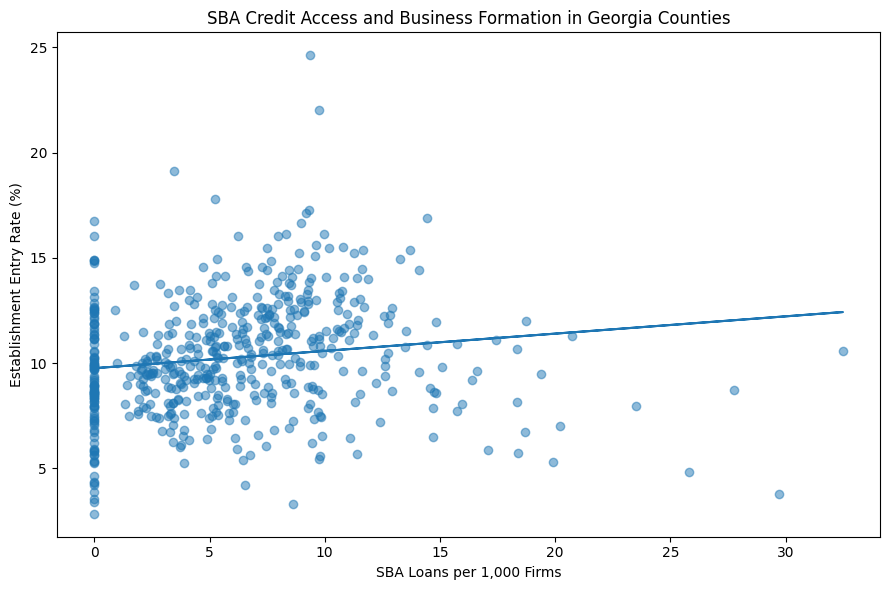

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Main visualization using county-years with at least 100 firms

x = stable_analysis["Loans_per_1000_Firms"]
y = stable_analysis["estabs_entry_rate"]

plt.figure(figsize=(9, 6))

plt.scatter(x, y, alpha=0.5)

# Simple fitted trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("SBA Loans per 1,000 Firms")
plt.ylabel("Establishment Entry Rate (%)")
plt.title("SBA Credit Access and Business Formation in Georgia Counties")

plt.tight_layout()
plt.show()

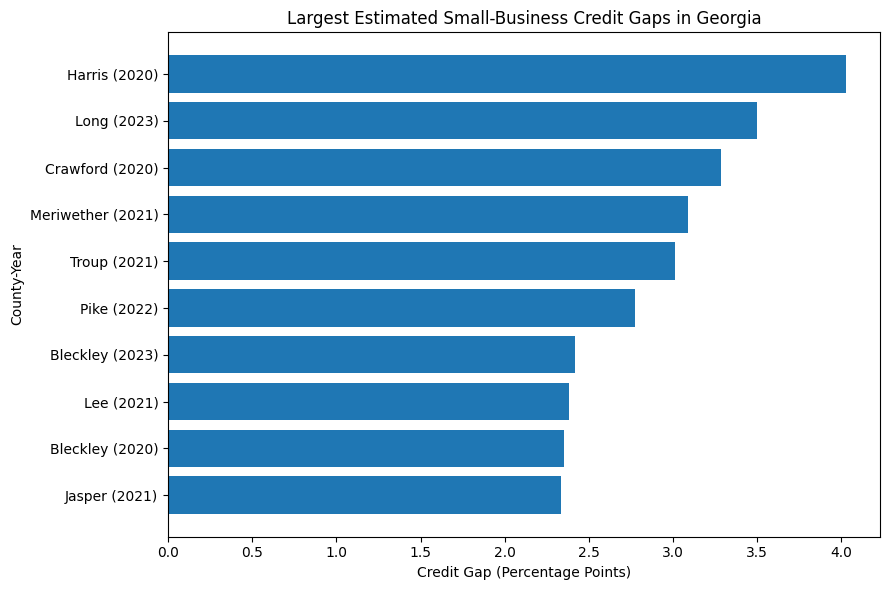

In [34]:
# Visualize the largest estimated credit gaps

plot_gaps = stable_gaps.head(10).copy()

# Create labels such as "Harris (2020)"
plot_gaps["label"] = (
    plot_gaps["county_name"].str.title()
    + " ("
    + plot_gaps["year"].astype(str)
    + ")"
)

# Reverse order so largest appears at top
plot_gaps = plot_gaps.sort_values("credit_gap")

plt.figure(figsize=(9, 6))

plt.barh(
    plot_gaps["label"],
    plot_gaps["credit_gap"]
)

plt.xlabel("Credit Gap (Percentage Points)")
plt.ylabel("County-Year")
plt.title("Largest Estimated Small-Business Credit Gaps in Georgia")

plt.tight_layout()
plt.show()

In [35]:
# Robustness check: only county-years with at least one SBA loan

positive_loans = analysis[
    analysis["Loans_per_1000_Firms"] > 0
].copy()

robust_model = smf.ols(
    "estabs_entry_rate ~ Loans_per_1000_Firms + C(year)",
    data=positive_loans
).fit()

print("County-years with SBA lending:", len(positive_loans))
print(
    "SBA loan coefficient:",
    round(robust_model.params["Loans_per_1000_Firms"], 4)
)
print(
    "P-value:",
    round(robust_model.pvalues["Loans_per_1000_Firms"], 4)
)
print(
    "R-squared:",
    round(robust_model.rsquared, 4)
)

County-years with SBA lending: 457
SBA loan coefficient: 0.0473
P-value: 0.0762
R-squared: 0.0856


In [36]:
# Create final model comparison table

results_table = pd.DataFrame({
    "Model": [
        "Main model",
        "100+ firms",
        "Positive SBA lending only"
    ],
    "Observations": [
        len(analysis),
        len(stable_analysis),
        len(positive_loans)
    ],
    "SBA Loan Coefficient": [
        model.params["Loans_per_1000_Firms"],
        stable_model.params["Loans_per_1000_Firms"],
        robust_model.params["Loans_per_1000_Firms"]
    ],
    "P-value": [
        model.pvalues["Loans_per_1000_Firms"],
        stable_model.pvalues["Loans_per_1000_Firms"],
        robust_model.pvalues["Loans_per_1000_Firms"]
    ],
    "R-squared": [
        model.rsquared,
        stable_model.rsquared,
        robust_model.rsquared
    ]
})

results_table = results_table.round({
    "SBA Loan Coefficient": 4,
    "P-value": 4,
    "R-squared": 4
})

results_table

,Model,Observations,SBA Loan Coefficient,P-value,R-squared
0,Main model,620,0.0731,0.0013,0.0731
1,100+ firms,539,0.0719,0.0027,0.0903
2,Positive SBA lending only,457,0.0473,0.0762,0.0856


### Robustness Interpretation

Excluding county-years with fewer than 100 firms produces an almost identical coefficient (0.0719 versus 0.0731 in the main model), and the relationship remains statistically significant. This suggests that the main finding is not driven primarily by very small county economies.

However, when the sample is restricted to county-years that received at least one SBA loan, the estimated coefficient falls to 0.0473 and is no longer statistically significant at the 5% level (p = 0.0762).

Together, these results suggest that the observed relationship may partly reflect differences between counties with and without SBA lending access, rather than a simple relationship in which progressively more SBA lending is always associated with progressively greater business formation.

## 10. Key Findings & Limitations

### Key Findings

Across Georgia counties from 2020–2023, greater SBA 7(a) lending intensity was positively associated with new-business formation. In the main year-controlled regression, 10 additional SBA loans per 1,000 existing firms were associated with approximately a 0.73 percentage-point higher establishment entry rate (p = 0.0013).

The relationship remained nearly unchanged after excluding county-years with fewer than 100 firms (0.72 percentage points per 10 additional loans; p = 0.0027), suggesting that the result was not driven primarily by very small county economies.

However, when the analysis was restricted to county-years receiving at least one SBA loan, the estimated relationship weakened and was no longer statistically significant at the 5% level (p = 0.0762). This suggests that differences in access to SBA lending may be particularly relevant, rather than simply the volume of lending among counties already receiving SBA loans.

The credit-gap analysis also identified county-years where relatively strong business formation coincided with comparatively low SBA lending, highlighting geographic areas that may warrant further investigation into small-business credit access.

### Limitations

This analysis identifies associations rather than causal effects. SBA lending may itself respond to local economic conditions, and factors such as population growth, income, industry composition, bank availability, and local policy could influence both lending and business formation.

SBA 7(a) lending also represents only one source of small-business financing and therefore should not be interpreted as a complete measure of credit availability.

Finally, the 2020–2023 period includes unusual pandemic-era economic conditions, which may limit how broadly the results generalize to other periods.